# Provenance Graphs

## What you'll learn

- Read macro graphs to understand pipeline topology at a glance
- Read micro graphs and use step-by-step snapshots to trace individual artifact derivation
- Walk multi-hop lineage chains programmatically

Artisan records two types of provenance as your pipeline runs:
**execution provenance** tracks which step ran which operation, consuming
and producing artifacts. **Artifact provenance** tracks which specific
output artifact was derived from which specific input artifact. This
tutorial shows you how to visualize both and how to query lineage in code.

**Prerequisites:** [Your First Pipeline](../getting-started/01-first-pipeline.ipynb),
[Exploring Results](../getting-started/02-exploring-results.ipynb).  
**Estimated time:** ~15 min.  
**GPU required:** No.

In [ ]:
from __future__ import annotations

from artisan.operations.curator import Filter
from artisan.operations.examples import (
    DataGenerator,
    DataTransformer,
    MetricCalculator,
)
from artisan.orchestration import Backend, PipelineManager
from artisan.storage import ArtifactStore
from artisan.storage.provenance_utils import trace_derived_artifacts
from artisan.utils import tutorial_setup
from artisan.utils.logging import configure_logging
from artisan.visualization import (
    build_macro_graph,
    build_micro_graph,
    inspect_pipeline,
)

configure_logging()

env = tutorial_setup("provenance_graphs")
DELTA_ROOT = env.delta_root

## Build a sample pipeline

The pipeline below generates data, transforms it, computes metrics,
filters by a metric threshold, and transforms the survivors. The branching
topology — step 1's output feeds both the metric computation
and the filter — creates a non-trivial provenance graph to
explore.

In [ ]:
pipeline = PipelineManager.create(
    name="provenance_tutorial",
    delta_root=env.delta_root,
    staging_root=env.staging_root,
    working_root=env.working_root,
)
output = pipeline.output

# Step 0: Generate 5 source datasets
pipeline.run(
    operation=DataGenerator,
    name="generate",
    params={"count": 5, "seed": 42},
    backend=Backend.LOCAL,
)

# Step 1: Transform each dataset
pipeline.run(
    operation=DataTransformer,
    name="transform",
    inputs={"dataset": output("generate", "datasets")},
    backend=Backend.LOCAL,
)

# Step 2: Compute metrics for each transformed dataset
pipeline.run(
    operation=MetricCalculator,
    name="score",
    inputs={"dataset": output("transform", "dataset")},
    backend=Backend.LOCAL,
)

# Step 3: Filter — keep datasets whose median > 0.3
pipeline.run(
    operation=Filter,
    name="filter",
    inputs={
        "passthrough": output("transform", "dataset"),
        "scores": output("score", "metrics"),
    },
    params={
        "criteria": [
            {"metric": "scores.distribution.median", "operator": "gt", "value": 0.3},
        ]
    },
    backend=Backend.LOCAL,
)

# Step 4: Transform the filtered results
pipeline.run(
    operation=DataTransformer,
    name="refine",
    inputs={"dataset": output("filter", "passthrough")},
    backend=Backend.LOCAL,
)

pipeline.finalize()
inspect_pipeline(DELTA_ROOT)

## Pipeline topology: the macro graph

The macro graph shows the pipeline at the **step level**: which operations
ran, what data flowed between them, and how many artifacts each step
produced. It's the fastest way to confirm your pipeline has the shape
you intended.

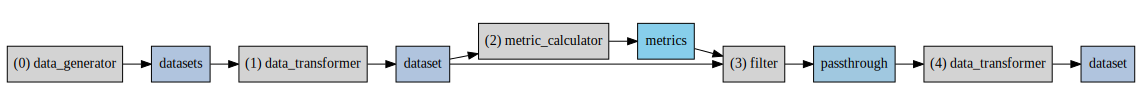

In [3]:
build_macro_graph(DELTA_ROOT)

### Reading the macro graph

The graph reads left to right:

| Element | Meaning |
|---|---|
| Grey rounded box | An execution step, labelled `(N) step_name` |
| Colored box | An artifact output, labelled with the output role and count |
| Arrow (step → data) | "This step produced these artifacts" |
| Arrow (data → step) | "This step consumed these artifacts" |

Notice two things in this pipeline:

1. **Branching at step 1.** Step 1's `dataset` output feeds *both* step 2
   (MetricCalculator) and step 3 (Filter). You can see this as two arrows
   leaving the same data node.

2. **Filter is passthrough.** Step 3 doesn't produce new artifact nodes
   with a distinct type — it routes a subset of existing artifacts through.
   The output count at step 3 is smaller than step 1's count because some
   artifacts were filtered out.

The macro graph answers questions like: *What's the overall shape of my
pipeline? Where does it branch? How many artifacts survived the filter?*
For artifact-level detail, you need the micro graph.

## Artifact lineage: the micro graph

The macro graph groups artifacts into counts per step. The micro graph
shows **every individual artifact** and the derivation edges between them.
This is where you can trace exactly which input produced which output.

`build_micro_graph` renders the full artifact-level provenance graph.
Use the `max_step` parameter to show only artifacts through a given step.

In [ ]:
build_micro_graph(DELTA_ROOT)

### Reading the micro graph

The micro graph above shows the full pipeline. Here's what to look for
at each step:

- **Step 0:** Five data artifact nodes appear with no incoming edges.
  These are *source artifacts* — the starting points of all lineage chains.

- **Step 1:** Five new data nodes appear. Each one is connected to a
  step-0 artifact by an **orange arrow** — that's an artifact provenance
  edge meaning "derived from." The grey execution box shows the
  DataTransformer operation.

- **Step 2:** Five metric nodes appear, each derived from a step-1 dataset.
  The graph now shows the branch: step-1 artifacts have edges going both
  right (to metrics at step 2) and down (to the filter at step 3).

- **Step 3:** No new artifact nodes appear. Filter is a passthrough — it
  selects a subset of step-1 artifacts without creating new ones. Only the
  surviving artifacts remain connected to downstream edges.

- **Step 4:** New data nodes appear, derived from the filtered subset.
  Artifacts that were filtered out at step 3 have no step-4 descendants.

**Visual legend:**

| Element | Meaning |
|---|---|
| Grey box | Execution record (an operation that ran) |
| Colored box | Artifact (a data, metric, or file artifact) |
| Black solid arrow | Execution provenance — "produced by" or "consumed by" |
| Orange arrow | Artifact provenance — "derived from" |
| Dashed arrow | Backward or passthrough reference |

### Step-by-step snapshots

Use `build_micro_graph` with `max_step` to render a cumulative snapshot
showing all artifacts and edges through a given step. This lets you
inspect how the provenance graph grows at each stage.

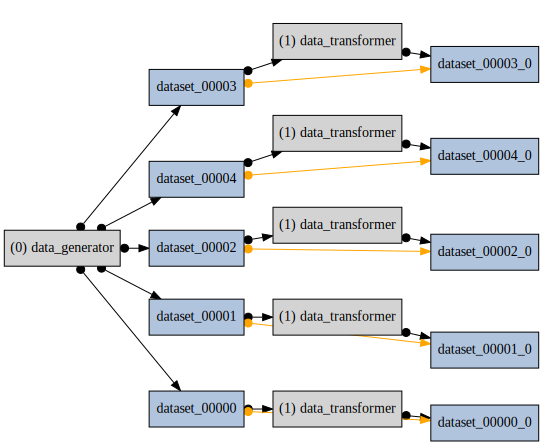

In [5]:
# After step 1: source generation + first transformation
build_micro_graph(DELTA_ROOT, max_step=1)

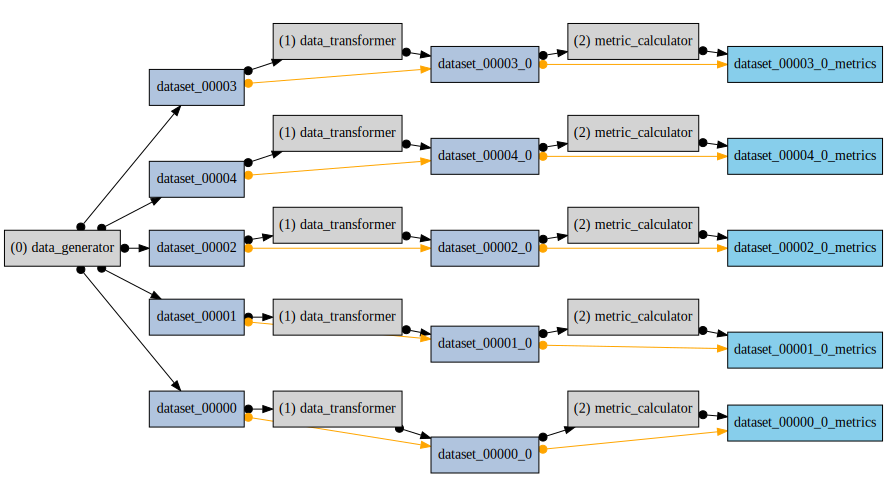

In [6]:
# After step 2: metrics branch off from the transformed datasets
build_micro_graph(DELTA_ROOT, max_step=2)

## Tracing lineage programmatically

Graphs are useful for exploration, but real workflows often need lineage
queries in code — to find where an artifact came from, to locate all
downstream results derived from a specific input, or to automate
quality checks.

`ArtifactStore` provides methods for tracing lineage in both directions.

### Tracing backward: where did this artifact come from?

Pick a metric artifact from step 2 and walk its lineage back to the
original source, one hop at a time.

In [8]:
store = ArtifactStore(DELTA_ROOT)

# Pick a metric artifact from step 2
metric_ids = store.load_artifact_ids_by_type("metric", step_numbers=[2])
metric_id = sorted(metric_ids)[0]
print(f"Starting from metric: {metric_id[:12]}... (step 2)")

# One hop back: what was this metric computed from?
parents = store.get_ancestor_artifact_ids(metric_id)
parent_id = parents[0]
parent_type = store.get_artifact_type(parent_id)
parent_step = store.get_artifact_step_number(parent_id)
print(f"  ← parent: {parent_id[:12]}... (type={parent_type}, step={parent_step})")

# Another hop back: where did that dataset come from?
grandparents = store.get_ancestor_artifact_ids(parent_id)
gp_id = grandparents[0]
gp_type = store.get_artifact_type(gp_id)
gp_step = store.get_artifact_step_number(gp_id)
print(f"  ← grandparent: {gp_id[:12]}... (type={gp_type}, step={gp_step})")

# Check if we've reached a source artifact
great_gps = store.get_ancestor_artifact_ids(gp_id)
if not great_gps:
    print("  ← source artifact (no further ancestors)")
else:
    print(f"  ← {len(great_gps)} more ancestor(s)")

Starting from metric: 4555842eaf96... (step 2)
  ← parent: e560282306e7... (type=data, step=1)
  ← grandparent: 7dbcc787ebe7... (type=data, step=0)
  ← source artifact (no further ancestors)


Starting from a metric at step 2, the lineage chain goes:
**metric (step 2) → dataset (step 1) → dataset (step 0)**.
The step-0 dataset is a source artifact with no ancestors — that's
where the chain ends.

This is the same information the micro graph shows visually. The
programmatic approach is useful when you need to automate this
kind of traversal across many artifacts.

### Tracing forward: what was derived from this artifact?

The reverse question is equally useful: given a source artifact, find
everything downstream that was derived from it.

In [9]:
# Pick a source dataset from step 0
source_ids = store.load_artifact_ids_by_type("data", step_numbers=[0])
source_id = sorted(source_ids)[0]
print(f"Starting from source: {source_id[:12]}... (step 0)")

# Load the forward provenance map (all edges, all steps)
forward_map = store.load_forward_provenance_map()

# Find all metric descendants
all_metric_ids = store.load_artifact_ids_by_type("metric")
derived_metrics = trace_derived_artifacts(source_id, forward_map, all_metric_ids)
print(f"  → {len(derived_metrics)} metric(s) derived from this source")

# Find all data descendants
all_data_ids = store.load_artifact_ids_by_type("data")
derived_data = trace_derived_artifacts(source_id, forward_map, all_data_ids)
print(f"  → {len(derived_data)} dataset(s) derived from this source")

# Show each descendant with its step number
all_derived = derived_data + derived_metrics
step_map = store.load_step_number_map(set(all_derived))
print("\nFull descendant tree:")
for aid in sorted(all_derived, key=lambda x: step_map.get(x, 99)):
    atype = store.get_artifact_type(aid)
    print(f"  step {step_map[aid]}: {atype} {aid[:12]}...")

Starting from source: 668d3c004800... (step 0)
  → 1 metric(s) derived from this source
  → 2 dataset(s) derived from this source

Full descendant tree:
  step 1: data 4eca663f6217...
  step 2: metric 8e3aebe375c1...
  step 4: data 3c4c3577091e...


From a single source dataset at step 0, you can see every artifact it
eventually contributed to: the transformed datasets at step 1, the
metrics at step 2, and (if it passed the filter) the final transformed
datasets at step 4.

This is a powerful tool for impact analysis. If you discover an issue
with a source artifact, forward tracing tells you exactly which
downstream results are affected.

## Which tool for which question

| Question | Tool |
|---|---|
| What's the shape of my pipeline? | `build_macro_graph` |
| How many artifacts survived the filter? | `build_macro_graph` or `inspect_pipeline` |
| Where did this specific artifact come from? | `build_micro_graph` |
| Which step-0 input led to this result? | `store.get_ancestor_artifact_ids` (walk backward) |
| What was downstream of this input? | `trace_derived_artifacts` (walk forward) |
| Is my pipeline wired correctly? | `build_macro_graph` first, then `build_micro_graph` for details |

## Summary

You learned three ways to explore provenance, each at a different
level of detail:

- **Macro graph** — step-level pipeline topology, for understanding the
  overall DAG shape and artifact flow.
- **Micro graph snapshots** — individual artifact nodes and derivation
  edges, for tracing exactly which input produced which output.
- **Programmatic queries** — `ArtifactStore` methods for walking lineage
  chains in code, both backward (ancestors) and forward (descendants).

## Next steps

- [Provenance System](../../concepts/provenance-system.md) — How the dual
  provenance model works under the hood
- [Inspecting Provenance](../../how-to-guides/inspecting-provenance.md) —
  Task-oriented recipes for common provenance queries
- [Exploring Results](../getting-started/02-exploring-results.ipynb) —
  Inspect helpers for pipeline data and metrics